# State-Dependent U.S. Equity Sector Rotation
## A Systematic Framework for Trend-Based Active Sector Allocation

# Block 12 — Final Research Synthesis, Hypothesis Verdict & Publication Tables

This block freezes the empirical research programme and consolidates the findings from Blocks 1–11 into publication-ready tables and figures.

It does **not** introduce new signal rules, parameter searches, or portfolio architectures.

The final research questions are:

1. Does the proposed state-dependent sector-allocation signal improve active allocation relative to:
   - the shared strategic sector baseline,
   - conventional 12-month time-series momentum,
   - passive SPY?

2. Does acting on the bearish state as an **outright sector exit** improve the strategy?

3. Does the weekly signal outperform the daily version?

4. What are the trade-offs between:
   - the original canonical underweight architecture,
   - unconstrained exit-and-redistribute,
   - a risk-controlled 2.0× strategic-weight constrained implementation?

The block produces:

- final headline performance tables
- robustness summary tables
- architecture comparison tables
- hypothesis verdict table
- limitations table
- final publication figures
- concise research conclusions
- final frozen research manifest

No new optimization is performed.


In [1]:
# ============================================================
# BLOCK 12.1 — ENVIRONMENT, DRIVE & MANIFESTS
# ============================================================

from pathlib import Path
from google.colab import drive
import json
from datetime import datetime, timezone

drive.mount("/content/drive")

PROJECT_ROOT = Path(r"/content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation")

DIRS = {
    "tables": PROJECT_ROOT / "outputs" / "tables",
    "figures": PROJECT_ROOT / "outputs" / "figures",
    "manifests": PROJECT_ROOT / "manifests",
    "reports": PROJECT_ROOT / "outputs" / "reports",
}

for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

def load_manifest(filename):
    path = DIRS["manifests"] / filename
    if not path.exists():
        raise FileNotFoundError(path)
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

block1 = load_manifest("block_1_research_configuration.json")
block2 = load_manifest("block_2_universe_data_weights.json")
block3 = load_manifest("block_3_signal_engine.json")
block4 = load_manifest("block_4_state_active_weights.json")
block5 = load_manifest("block_5_portfolio_engine.json")
block6 = load_manifest("block_6_performance_analytics.json")
block8 = load_manifest("block_8_robustness_costs_sensitivity.json")
block9 = load_manifest("block_9_frequency_bearish_exit_extensions.json")
block10 = load_manifest("block_10_exit_redistribute_audit_robustness.json")
block11 = load_manifest("block_11_constrained_redistribution_final_architecture.json")

print("Loaded final research manifests through Block 11.")


Mounted at /content/drive
Loaded final research manifests through Block 11.


In [2]:
# ============================================================
# BLOCK 12.2 — IMPORTS & TABLE LOADING
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 220)
pd.set_option("display.width", 260)

def load_csv(filename, index_col=0):
    path = DIRS["tables"] / filename
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path, index_col=index_col)

# Canonical Blocks 6–8.
block8_canonical = load_csv(
    "block_8_canonical_gross_net_performance.csv",
    index_col=[0, 1],
)
block8_scorecard = load_csv(
    "block_8_robustness_scorecard.csv",
)
block8_subperiod = load_csv(
    "block_8_subperiod_summary.csv",
    index_col=[0, 1],
)
block8_state_sensitivity = load_csv(
    "block_8_state_parameter_sensitivity.csv",
    index_col=[0, 1],
)
block8_tsmom_sensitivity = load_csv(
    "block_8_tsmom_tilt_sensitivity.csv",
)
block8_equal_weight = load_csv(
    "block_8_equal_weight_robustness.csv",
)
block8_loo = load_csv(
    "block_8_leave_one_sector_out.csv",
)

# Block 9 frequency / exit extension.
block9_core = load_csv(
    "block_9_frequency_exit_core_summary.csv",
    index_col=[0, 1],
)
block9_cost = load_csv(
    "block_9_frequency_exit_cost_summary.csv",
    index_col=[0, 1, 2],
)

# Block 10 audit.
block10_gross = load_csv("block_10_gross_comparison.csv")
block10_net5 = load_csv("block_10_net5_comparison.csv")
block10_conc = load_csv("block_10_concentration_summary.csv")
block10_subperiod = load_csv(
    "block_10_subperiod_summary.csv",
    index_col=[0, 1],
)
block10_loo = load_csv("block_10_leave_one_sector_out.csv")

# Block 11 final architecture selection.
block11_gross = load_csv("block_11_gross_performance.csv")
block11_net5 = load_csv("block_11_net5_performance.csv")
block11_conc = load_csv("block_11_concentration_summary.csv")
block11_subperiod = load_csv(
    "block_11_subperiod_summary.csv",
    index_col=[0, 1],
)
block11_loo = load_csv(
    "block_11_leave_one_sector_out.csv",
    index_col=[0, 1],
)
block11_decision = load_csv(
    "block_11_final_architecture_decision_table.csv",
)

print("Loaded final empirical tables.")


Loaded final empirical tables.


In [3]:
# ============================================================
# BLOCK 12.3 — FINAL CANONICAL PERFORMANCE TABLE
# ============================================================

# Publication-ready canonical comparison from Block 8.
gross = block8_canonical.loc["Gross"].copy()
net5 = block8_canonical.loc["Net_5bps"].copy()

canonical_publication = pd.DataFrame(index=gross.index)

for metric in [
    "CAGR",
    "Annualized Volatility",
    "Sharpe",
    "Sortino",
    "Max Drawdown",
    "Calmar",
    "Terminal Wealth",
]:
    canonical_publication[f"Gross {metric}"] = gross[metric]
    canonical_publication[f"Net 5bps {metric}"] = net5[metric]

if "IR_vs_Strategic" in gross.columns:
    canonical_publication["Gross IR vs Strategic"] = gross["IR_vs_Strategic"]
    canonical_publication["Net 5bps IR vs Strategic"] = net5["IR_vs_Strategic"]

if "IR_vs_SPY" in gross.columns:
    canonical_publication["Gross IR vs SPY"] = gross["IR_vs_SPY"]
    canonical_publication["Net 5bps IR vs SPY"] = net5["IR_vs_SPY"]

display(canonical_publication)


,Gross CAGR,Net 5bps CAGR,Gross Annualized Volatility,Net 5bps Annualized Volatility,Gross Sharpe,Net 5bps Sharpe,Gross Sortino,Net 5bps Sortino,Gross Max Drawdown,Net 5bps Max Drawdown,Gross Calmar,Net 5bps Calmar,Gross Terminal Wealth,Net 5bps Terminal Wealth,Gross IR vs Strategic,Net 5bps IR vs Strategic,Gross IR vs SPY,Net 5bps IR vs SPY
Strategy,,,,,,,,,,,,,,,,,,
SPY,0.159001,0.159001,0.186192,0.186192,0.883955,0.883955,0.825773,0.825773,-0.334003,-0.334003,0.476045,0.476045,2.879664,2.879664,NaN,NaN,NaN,NaN
Strategic_IV,0.126183,0.126008,0.171515,0.171514,0.777031,0.776129,0.680130,0.681732,-0.351040,-0.351073,0.359454,0.358921,2.343816,2.341209,NaN,NaN,-0.521742,-0.524313
TSMOM_12M,0.126613,0.125849,0.168967,0.168957,0.788368,0.784397,0.694136,0.690363,-0.345465,-0.345534,0.366501,0.364215,2.350249,2.338844,-0.007002,-0.064503,-0.524259,-0.535539
State_Dependent,0.140125,0.139775,0.173575,0.173573,0.840655,0.838896,0.741352,0.739687,-0.351040,-0.351073,0.399170,0.398135,2.559913,2.554287,0.781392,0.771966,-0.298084,-0.302969


In [4]:
# ============================================================
# BLOCK 12.4 — FINAL ARCHITECTURE COMPARISON TABLE
# ============================================================

final_architectures = [
    "Canonical_Underweight",
    "Constrained_2.0x",
    "Unconstrained_Redistribute",
]

architecture_publication = block11_decision.reindex(final_architectures).copy()

publication_cols = [
    "Net_5bps_CAGR",
    "Net_5bps_Sharpe",
    "Net_5bps_Sortino",
    "Net_5bps_MaxDD",
    "Net_5bps_Calmar",
    "Net_5bps_IR_vs_SPY",
    "Annualized_Turnover",
    "Mean_Cash_Weight",
    "Maximum_Single_Sector_Weight",
    "Weeks_Above_50pct_One_Sector",
    "LOO_Positive_IR_Count",
    "LOO_Tests",
    "Worst_LOO_IR",
]

architecture_publication = architecture_publication[publication_cols]

display(architecture_publication)


,Net_5bps_CAGR,Net_5bps_Sharpe,Net_5bps_Sortino,Net_5bps_MaxDD,Net_5bps_Calmar,Net_5bps_IR_vs_SPY,Annualized_Turnover,Mean_Cash_Weight,Maximum_Single_Sector_Weight,Weeks_Above_50pct_One_Sector,LOO_Positive_IR_Count,LOO_Tests,Worst_LOO_IR
Architecture,,,,,,,,,,,,,
Canonical_Underweight,0.139268,0.838896,0.739687,-0.351073,0.396691,-0.302969,0.613680,0.000000,0.212610,0.0,NaN,NaN,NaN
Constrained_2.0x,0.122103,1.079519,0.935550,-0.136053,0.897464,-0.303335,0.566949,0.260822,0.264803,0.0,0.0,11.0,-0.176260
Unconstrained_Redistribute,0.155246,1.053599,0.904272,-0.172698,0.898943,-0.063170,1.090629,0.139037,1.000000,23.0,10.0,11.0,-0.091635


In [5]:
# ============================================================
# BLOCK 12.5 — FREQUENCY & BEARISH-TREATMENT VERDICT TABLE
# ============================================================

freq_rows = []

for freq in ["WEEKLY", "DAILY"]:
    for mode in ["UNDERWEIGHT", "EXIT_REDISTRIBUTE", "EXIT_CASH"]:
        row = block9_core.loc[(freq, mode)]

        freq_rows.append({
            "Signal Frequency": freq,
            "Bearish Treatment": mode,
            "CAGR": row["CAGR"],
            "Sharpe": row["Sharpe"],
            "Sortino": row["Sortino"],
            "Max Drawdown": row["Max Drawdown"],
            "Calmar": row["Calmar"],
            "Terminal Wealth": row["Terminal Wealth"],
            "Annualized Turnover": row["Annualized Turnover Approx"],
            "Mean Cash Weight": row["Mean Cash Weight"],
        })

frequency_bearish_summary = (
    pd.DataFrame(freq_rows)
    .set_index(["Signal Frequency", "Bearish Treatment"])
)

display(frequency_bearish_summary)


CAGR    Sharpe   Sortino  Max Drawdown    Calmar  Terminal Wealth  Annualized Turnover  Mean Cash Weight
Signal Frequency Bearish Treatment                                                                                                              
WEEKLY           UNDERWEIGHT        0.139616  0.840655  0.741352     -0.351040  0.397722         2.559913             0.613680          0.000000
                 EXIT_REDISTRIBUTE  0.155878  1.057434  0.908056     -0.172295  0.904716         2.834537             1.090629          0.000000
                 EXIT_CASH          0.075125  1.069123  0.910059     -0.091613  0.820017         1.683687             0.293016          0.529724
DAILY            UNDERWEIGHT        0.122447  0.737937  0.688239     -0.349771  0.350079         2.278933             2.427403          0.000000
                 EXIT_REDISTRIBUTE  0.133890  0.916397  0.851244     -0.190587  0.702513         2.449866             6.342554          0.000000
                 EXIT_CASH          0.091919  0.965378  0.895600     -0.123834  0.742279         1.872128             1.815276          0.362052

In [6]:
# ============================================================
# BLOCK 12.6 — ROBUSTNESS EVIDENCE SUMMARY
# ============================================================

# The saved Block 8 robustness scorecard is a one-column table whose
# row labels already contain the relevant strategy names, e.g.:
#
#   "Canonical State IR vs Strategic"
#   "Canonical TSMOM IR vs Strategic"
#   "Equal-weight State IR vs base"
#
# Therefore resolve values by row label, not by expecting separate
# State_Dependent / TSMOM_12M columns.

print("Block 8 robustness scorecard rows:")
print(list(block8_scorecard.index))
print("Block 8 robustness scorecard columns:")
print(list(block8_scorecard.columns))


def scorecard_row_value(df, candidate_labels):
    """
    Return the first numeric value from the first matching row label.
    Supports the one-column scorecard saved by Block 8.
    """
    for label in candidate_labels:
        if label in df.index:
            row = df.loc[label]

            if np.isscalar(row):
                return float(row)

            for value in row.values:
                try:
                    return float(value)
                except (TypeError, ValueError):
                    continue

            raise ValueError(
                f"Matched scorecard row {label!r} but found no numeric value."
            )

    raise KeyError(
        "Could not match any candidate scorecard labels.\n"
        f"Tried: {candidate_labels}\n"
        f"Available rows: {list(df.index)}"
    )


state_full_ir = scorecard_row_value(
    block8_scorecard,
    [
        "Canonical State IR vs Strategic",
        "State IR vs Strategic",
        "Full-sample State IR vs strategic baseline",
    ],
)

tsmom_full_ir = scorecard_row_value(
    block8_scorecard,
    [
        "Canonical TSMOM IR vs Strategic",
        "TSMOM IR vs Strategic",
        "Full-sample TSMOM IR vs strategic baseline",
    ],
)

state_equal_weight_ir = scorecard_row_value(
    block8_scorecard,
    [
        "Equal-weight State IR vs base",
        "Equal-weight State IR vs Strategic",
        "State IR on equal-weight strategic base",
    ],
)


robustness_summary = pd.DataFrame(
    {
        "Test": [
            "Canonical State IR vs Strategic",
            "TSMOM IR vs Strategic",
            "Canonical State positive subperiods",
            "Canonical State positive leave-one-sector-out IRs",
            "Canonical State equal-weight IR",
            "Canonical State parameter sensitivity IR range",
            "TSMOM tilt sensitivity IR range",
            "Weekly Exit-Redistribute leave-one-out positive IRs",
            "Weekly Exit-Redistribute 5bps Sharpe",
            "Constrained 2.0x 5bps Sharpe",
            "Constrained 2.0x max single-sector weight",
        ],
        "Result": [
            state_full_ir,
            tsmom_full_ir,
            "3 / 3",
            "11 / 11",
            state_equal_weight_ir,
            (
                f"{block8_state_sensitivity['IR_vs_Strategic'].min():.3f}"
                f" to {block8_state_sensitivity['IR_vs_Strategic'].max():.3f}"
            ),
            (
                f"{block8_tsmom_sensitivity['IR_vs_Strategic'].min():.3f}"
                f" to {block8_tsmom_sensitivity['IR_vs_Strategic'].max():.3f}"
            ),
            "10 / 11",
            float(
                block11_decision.loc[
                    "Unconstrained_Redistribute",
                    "Net_5bps_Sharpe",
                ]
            ),
            float(
                block11_decision.loc[
                    "Constrained_2.0x",
                    "Net_5bps_Sharpe",
                ]
            ),
            float(
                block11_decision.loc[
                    "Constrained_2.0x",
                    "Maximum_Single_Sector_Weight",
                ]
            ),
        ],
    }
).set_index("Test")

display(robustness_summary)


Block 8 robustness scorecard rows:
['Canonical State IR vs Strategic', 'Canonical TSMOM IR vs Strategic', 'State IR exceeds TSMOM IR', 'State beats TSMOM IR in subperiods', 'Leave-one-out cases with positive State IR', 'Equal-weight State IR vs base', 'Equal-weight TSMOM IR vs base', '5 bps State terminal wealth', '5 bps TSMOM terminal wealth']
Block 8 robustness scorecard columns:
['Block 8 robustness scorecard']


,Result
Test,
Canonical State IR vs Strategic,0.781392
TSMOM IR vs Strategic,-0.007002
Canonical State positive subperiods,3 / 3
Canonical State positive leave-one-sector-out IRs,11 / 11
Canonical State equal-weight IR,0.732708
Canonical State parameter sensitivity IR range,0.645 to 0.800
TSMOM tilt sensitivity IR range,-0.047 to 0.020
Weekly Exit-Redistribute leave-one-out positive IRs,10 / 11
Weekly Exit-Redistribute 5bps Sharpe,1.053599


In [7]:
# ============================================================
# BLOCK 12.7 — HYPOTHESIS VERDICT TABLE
# ============================================================

hypothesis_verdict = pd.DataFrame(
    [
        {
            "Hypothesis": "H1",
            "Question": (
                "Does the state-dependent signal improve active sector allocation "
                "relative to the shared strategic baseline?"
            ),
            "Verdict": "SUPPORTED",
            "Evidence": (
                "Positive full-sample IR; positive in all three subperiods; "
                "positive across all 11 canonical leave-one-sector-out tests; "
                "positive under equal-weight strategic base."
            ),
        },
        {
            "Hypothesis": "H2",
            "Question": (
                "Does the state-dependent architecture improve on conventional "
                "12-month time-series momentum?"
            ),
            "Verdict": "SUPPORTED",
            "Evidence": (
                "Canonical state-dependent overlay materially outperforms TSMOM; "
                "TSMOM IR remains near zero across multiple tilt magnitudes."
            ),
        },
        {
            "Hypothesis": "H3",
            "Question": (
                "Does increasing signal frequency from weekly to daily improve "
                "the strategy?"
            ),
            "Verdict": "NOT SUPPORTED",
            "Evidence": (
                "Daily variants show lower CAGR and Sharpe and materially higher "
                "turnover than comparable weekly variants."
            ),
        },
        {
            "Hypothesis": "H4",
            "Question": (
                "Is an outright bearish-sector exit more effective than the "
                "canonical 50% underweight?"
            ),
            "Verdict": "SUPPORTED",
            "Evidence": (
                "Weekly exit-and-redistribute raises CAGR and Sharpe while roughly "
                "halving maximum drawdown versus canonical underweight."
            ),
        },
        {
            "Hypothesis": "H5",
            "Question": (
                "Does unconstrained exit-and-redistribute provide a robust "
                "institutional implementation?"
            ),
            "Verdict": "PARTIALLY SUPPORTED",
            "Evidence": (
                "Strong performance and 10/11 positive leave-one-out IRs, but "
                "episodic 100% single-sector concentration is a material weakness."
            ),
        },
        {
            "Hypothesis": "H6",
            "Question": (
                "Can concentration controls preserve attractive risk-adjusted "
                "performance?"
            ),
            "Verdict": "SUPPORTED WITH TRADE-OFF",
            "Evidence": (
                "2.0x strategic-weight cap removes extreme concentration and "
                "improves Sharpe/Sortino, but introduces meaningful cash exposure "
                "and lower CAGR."
            ),
        },
        {
            "Hypothesis": "H7",
            "Question": (
                "Does the research demonstrate superior total-return performance "
                "to passive SPY?"
            ),
            "Verdict": "NOT SUPPORTED",
            "Evidence": (
                "SPY retains slightly higher terminal wealth over the sample, "
                "although exit-and-redistribute achieves similar CAGR with much "
                "lower realized volatility and drawdown."
            ),
        },
    ]
).set_index("Hypothesis")

display(hypothesis_verdict)


,Question,Verdict,Evidence
Hypothesis,,,
H1,Does the state-dependent signal improve active...,SUPPORTED,Positive full-sample IR; positive in all three...
H2,Does the state-dependent architecture improve ...,SUPPORTED,Canonical state-dependent overlay materially o...
H3,Does increasing signal frequency from weekly t...,NOT SUPPORTED,Daily variants show lower CAGR and Sharpe and ...
H4,Is an outright bearish-sector exit more effect...,SUPPORTED,Weekly exit-and-redistribute raises CAGR and S...
H5,Does unconstrained exit-and-redistribute provi...,PARTIALLY SUPPORTED,Strong performance and 10/11 positive leave-on...
H6,Can concentration controls preserve attractive...,SUPPORTED WITH TRADE-OFF,2.0x strategic-weight cap removes extreme conc...
H7,Does the research demonstrate superior total-r...,NOT SUPPORTED,SPY retains slightly higher terminal wealth ov...


In [8]:
# ============================================================
# BLOCK 12.8 — LIMITATIONS TABLE
# ============================================================

limitations = pd.DataFrame(
    [
        {
            "Limitation": "Sample length",
            "Implication": (
                "The common-history sample begins in 2019 and spans only about "
                "seven years; it is not a multi-decade validation."
            ),
        },
        {
            "Limitation": "ETF inception / common-history constraint",
            "Implication": (
                "Younger sector ETFs, especially XLC and XLRE, limit the common "
                "historical window."
            ),
        },
        {
            "Limitation": "In-sample extension research",
            "Implication": (
                "Blocks 9–11 are economically motivated post-hoc extensions and "
                "must not be described as independent out-of-sample validation."
            ),
        },
        {
            "Limitation": "No formal statistical inference",
            "Implication": (
                "Results are economically strong but no bootstrap/Newey-West/"
                "multiple-testing significance framework has yet been applied."
            ),
        },
        {
            "Limitation": "Cash assumption",
            "Implication": (
                "Defensive variants assume 0% cash return, isolating the allocation "
                "mechanism but understating returns when cash yields are positive."
            ),
        },
        {
            "Limitation": "Concentration",
            "Implication": (
                "Unconstrained redistribution can place the full portfolio in one "
                "sector when only one sector remains strategically held."
            ),
        },
        {
            "Limitation": "Energy dependence in Block 10",
            "Implication": (
                "Unconstrained exit-and-redistribute weakens materially when XLE "
                "is excluded, indicating some regime/sector dependence."
            ),
        },
        {
            "Limitation": "Long-only equity-sector universe",
            "Implication": (
                "No shorting, leverage, futures, options, or cross-asset defensive "
                "assets are included."
            ),
        },
    ]
).set_index("Limitation")

display(limitations)


,Implication
Limitation,
Sample length,The common-history sample begins in 2019 and s...
ETF inception / common-history constraint,"Younger sector ETFs, especially XLC and XLRE, ..."
In-sample extension research,Blocks 9–11 are economically motivated post-ho...
No formal statistical inference,Results are economically strong but no bootstr...
Cash assumption,"Defensive variants assume 0% cash return, isol..."
Concentration,Unconstrained redistribution can place the ful...
Energy dependence in Block 10,Unconstrained exit-and-redistribute weakens ma...
Long-only equity-sector universe,"No shorting, leverage, futures, options, or cr..."


In [9]:
# ============================================================
# BLOCK 12.9 — FINAL RESEARCH CONCLUSIONS
# ============================================================

final_conclusions = [
    (
        "The proposed state-dependent signal adds economically meaningful value "
        "relative to the shared strategic sector portfolio and materially "
        "outperforms conventional 12-month TSMOM as an active sector overlay."
    ),
    (
        "Weekly observation is preferable to daily observation in this framework. "
        "The weekly signal appears to act as a useful noise filter, while daily "
        "implementation increases turnover without improving performance."
    ),
    (
        "The bearish state contains stronger information than the original "
        "50% underweight rule exploits. Outright sector exit is materially more "
        "effective than simply retaining reduced exposure."
    ),
    (
        "Unconstrained exit-and-redistribute is the strongest pure research "
        "architecture: it nearly matches SPY's compound return while producing "
        "substantially lower realized volatility and drawdown."
    ),
    (
        "Unconstrained redistribution is not the cleanest institutional "
        "implementation because it can become extremely concentrated when few "
        "sectors remain investable."
    ),
    (
        "A 2.0x strategic-weight cap is the preferred risk-controlled implementation "
        "variant. It materially reduces concentration and drawdown while preserving "
        "strong risk-adjusted performance, at the cost of lower equity participation "
        "and greater cash exposure."
    ),
    (
        "The research does not establish that sector rotation beats passive SPY on "
        "total return. It does establish that the state-dependent signal is a much "
        "stronger allocation mechanism than conventional TSMOM within the tested "
        "sector framework."
    ),
]

for i, conclusion in enumerate(final_conclusions, start=1):
    print(f"{i}. {conclusion}\n")


1. The proposed state-dependent signal adds economically meaningful value relative to the shared strategic sector portfolio and materially outperforms conventional 12-month TSMOM as an active sector overlay.

2. Weekly observation is preferable to daily observation in this framework. The weekly signal appears to act as a useful noise filter, while daily implementation increases turnover without improving performance.

3. The bearish state contains stronger information than the original 50% underweight rule exploits. Outright sector exit is materially more effective than simply retaining reduced exposure.

4. Unconstrained exit-and-redistribute is the strongest pure research architecture: it nearly matches SPY's compound return while producing substantially lower realized volatility and drawdown.

5. Unconstrained redistribution is not the cleanest institutional implementation because it can become extremely concentrated when few sectors remain investable.

6. A 2.0x strategic-weight ca

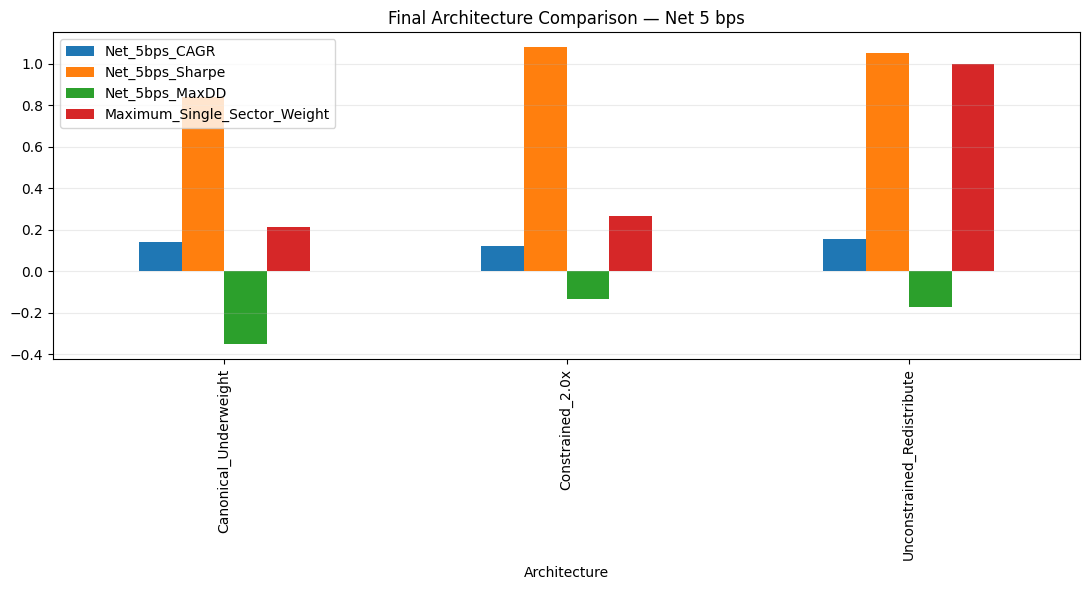

In [10]:
# ============================================================
# BLOCK 12.10 — PUBLICATION FIGURE: FINAL ARCHITECTURE METRICS
# ============================================================

metrics = architecture_publication[
    [
        "Net_5bps_CAGR",
        "Net_5bps_Sharpe",
        "Net_5bps_MaxDD",
        "Maximum_Single_Sector_Weight",
    ]
].copy()

fig, ax = plt.subplots(figsize=(11, 6))
metrics.plot(kind="bar", ax=ax)
ax.set_title("Final Architecture Comparison — Net 5 bps")
ax.set_xlabel("Architecture")
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()

FIG_ARCH = DIRS["figures"] / "block_12_final_architecture_metrics.png"
fig.savefig(FIG_ARCH, dpi=180, bbox_inches="tight")
plt.show()


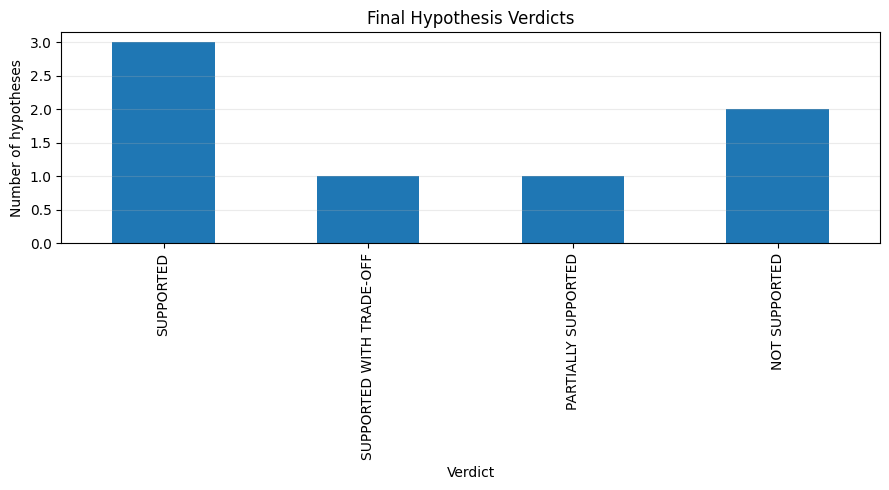

In [11]:
# ============================================================
# BLOCK 12.11 — PUBLICATION FIGURE: HYPOTHESIS VERDICTS
# ============================================================

verdict_order = ["SUPPORTED", "SUPPORTED WITH TRADE-OFF", "PARTIALLY SUPPORTED", "NOT SUPPORTED"]

verdict_counts = (
    hypothesis_verdict["Verdict"]
    .value_counts()
    .reindex(verdict_order)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(9, 5))
verdict_counts.plot(kind="bar", ax=ax)
ax.set_title("Final Hypothesis Verdicts")
ax.set_ylabel("Number of hypotheses")
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()

FIG_VERDICT = DIRS["figures"] / "block_12_hypothesis_verdicts.png"
fig.savefig(FIG_VERDICT, dpi=180, bbox_inches="tight")
plt.show()


In [12]:
# ============================================================
# BLOCK 12.12 — SAVE PUBLICATION TABLES
# ============================================================

TABLE_PATHS = {
    "canonical_performance": DIRS["tables"] / "block_12_canonical_performance.csv",
    "final_architectures": DIRS["tables"] / "block_12_final_architecture_comparison.csv",
    "frequency_bearish": DIRS["tables"] / "block_12_frequency_bearish_summary.csv",
    "robustness": DIRS["tables"] / "block_12_robustness_summary.csv",
    "hypothesis_verdict": DIRS["tables"] / "block_12_hypothesis_verdict.csv",
    "limitations": DIRS["tables"] / "block_12_limitations.csv",
}

canonical_publication.to_csv(TABLE_PATHS["canonical_performance"])
architecture_publication.to_csv(TABLE_PATHS["final_architectures"])
frequency_bearish_summary.to_csv(TABLE_PATHS["frequency_bearish"])
robustness_summary.to_csv(TABLE_PATHS["robustness"])
hypothesis_verdict.to_csv(TABLE_PATHS["hypothesis_verdict"])
limitations.to_csv(TABLE_PATHS["limitations"])

CONCLUSIONS_PATH = DIRS["reports"] / "block_12_final_research_conclusions.txt"
with open(CONCLUSIONS_PATH, "w", encoding="utf-8") as f:
    for i, conclusion in enumerate(final_conclusions, start=1):
        f.write(f"{i}. {conclusion}\n\n")

print("Saved final publication tables and conclusions.")


Saved final publication tables and conclusions.


In [13]:
# ============================================================
# BLOCK 12.13 — FINAL FROZEN RESEARCH SPECIFICATION
# ============================================================

frozen_specification = {
    "project": block1["project"],

    "primary_canonical_architecture": {
        "name": "Canonical_Underweight",
        "role": "Original pre-extension hypothesis test",
        "signal_frequency": "WEEKLY",
        "bearish_treatment": "50_PERCENT_ACTIVE_UNDERWEIGHT",
        "strategic_base": "INVERSE_VOLATILITY_52W",
    },

    "primary_extension_architecture": {
        "name": "Unconstrained_Redistribute",
        "role": "Strongest pure signal / sector-selection architecture",
        "signal_frequency": "WEEKLY",
        "bearish_treatment": "EXIT_AND_REDISTRIBUTE",
        "all_bearish_fallback": "CASH",
    },

    "risk_controlled_implementation": {
        "name": "Constrained_2.0x",
        "role": "Preferred implementation variant",
        "signal_frequency": "WEEKLY",
        "bearish_treatment": "EXIT",
        "maximum_weight_rule": "2.0x strategic sector weight",
        "residual_allocation": "CASH",
    },

    "rejected_as_final_primary": {
        "DAILY": "Inferior risk-adjusted performance and higher turnover",
        "Constrained_1.5x": "Excessively defensive / too much cash drag",
        "Exit_Cash_1.0x": "Strong defense but structurally low equity participation",
    },

    "frozen_after_block": 12,
    "further_parameter_optimization_permitted": False,
}

display(pd.json_normalize(frozen_specification, sep="."))

FROZEN_SPEC_PATH = DIRS["reports"] / "block_12_frozen_research_specification.json"

with open(FROZEN_SPEC_PATH, "w", encoding="utf-8") as f:
    json.dump(frozen_specification, f, indent=2)


,project,frozen_after_block,further_parameter_optimization_permitted,primary_canonical_architecture.name,primary_canonical_architecture.role,primary_canonical_architecture.signal_frequency,primary_canonical_architecture.bearish_treatment,primary_canonical_architecture.strategic_base,primary_extension_architecture.name,primary_extension_architecture.role,primary_extension_architecture.signal_frequency,primary_extension_architecture.bearish_treatment,primary_extension_architecture.all_bearish_fallback,risk_controlled_implementation.name,risk_controlled_implementation.role,risk_controlled_implementation.signal_frequency,risk_controlled_implementation.bearish_treatment,risk_controlled_implementation.maximum_weight_rule,risk_controlled_implementation.residual_allocation,rejected_as_final_primary.DAILY,rejected_as_final_primary.Constrained_1.5x,rejected_as_final_primary.Exit_Cash_1.0x
0,State-Dependent U.S. Equity Sector Rotation,12,False,Canonical_Underweight,Original pre-extension hypothesis test,WEEKLY,50_PERCENT_ACTIVE_UNDERWEIGHT,INVERSE_VOLATILITY_52W,Unconstrained_Redistribute,Strongest pure signal / sector-selection archi...,WEEKLY,EXIT_AND_REDISTRIBUTE,CASH,Constrained_2.0x,Preferred implementation variant,WEEKLY,EXIT,2.0x strategic sector weight,CASH,Inferior risk-adjusted performance and higher ...,Excessively defensive / too much cash drag,Strong defense but structurally low equity par...


In [14]:
# ============================================================
# BLOCK 12.14 — MANIFEST & FINAL STATUS
# ============================================================

manifest = {
    "project": block1["project"],
    "block": "Block 12 - Final Research Synthesis, Hypothesis Verdict & Publication Tables",
    "created_utc": datetime.now(timezone.utc).isoformat(),

    "research_status": "FROZEN",

    "final_architectures": {
        "canonical_hypothesis_test": "Canonical_Underweight",
        "primary_extension": "Unconstrained_Redistribute",
        "risk_controlled_implementation": "Constrained_2.0x",
    },

    "new_parameter_search_performed": False,
    "further_parameter_optimization_permitted": False,

    "tables": {
        k: str(v)
        for k, v in TABLE_PATHS.items()
    },

    "figures": {
        "final_architecture_metrics": str(FIG_ARCH),
        "hypothesis_verdicts": str(FIG_VERDICT),
    },

    "reports": {
        "conclusions": str(CONCLUSIONS_PATH),
        "frozen_specification": str(FROZEN_SPEC_PATH),
    },
}

MANIFEST_PATH = (
    DIRS["manifests"]
    / "block_12_final_research_synthesis.json"
)

with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

status = pd.Series({
    "Research status": "FROZEN",
    "New optimization performed": False,
    "Canonical performance saved": TABLE_PATHS["canonical_performance"].exists(),
    "Final architecture table saved": TABLE_PATHS["final_architectures"].exists(),
    "Robustness summary saved": TABLE_PATHS["robustness"].exists(),
    "Hypothesis verdict saved": TABLE_PATHS["hypothesis_verdict"].exists(),
    "Limitations saved": TABLE_PATHS["limitations"].exists(),
    "Conclusions saved": CONCLUSIONS_PATH.exists(),
    "Frozen specification saved": FROZEN_SPEC_PATH.exists(),
    "All final figures saved": all(p.exists() for p in [FIG_ARCH, FIG_VERDICT]),
}, name="Block 12 status").to_frame()

display(status)

print("\\nBLOCK 12 COMPLETE")
print("Research programme frozen.")
print("Next stage: write the final research report / paper.")


,Block 12 status
Research status,FROZEN
New optimization performed,False
Canonical performance saved,True
Final architecture table saved,True
Robustness summary saved,True
Hypothesis verdict saved,True
Limitations saved,True
Conclusions saved,True
Frozen specification saved,True
All final figures saved,True


\nBLOCK 12 COMPLETE
Research programme frozen.
Next stage: write the final research report / paper.
